In [1]:
import os, re, math, hashlib, warnings, numpy as np, pandas as pd
from io import BytesIO
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

import requests
from transformers import CLIPModel, CLIPProcessor

In [6]:
# ============================================================
# GOSSIPCOP DATASET — CLEAN DATA QUALITY & DUPLICATE AUDIT
# ============================================================


import os
import pandas as pd

# ------------------------------------------------------------
# DATASET PATHS
# ------------------------------------------------------------

FILES = {
    "1. Manifest":
        "/kaggle/input/datasets/rejuyanhossainshawon/gossip-dataset/manifest.csv",

    "2. Crawled":
        "/kaggle/input/datasets/rejuyanhossainshawon/gossip-dataset/crawled.csv",

    "3. Merged Best Image":
        "/kaggle/input/datasets/rejuyanhossainshawon/clean-gossip-data/merged_bestimg_11431.csv",

    "4. Final Multimodal":
        "/kaggle/input/datasets/rejuyanhossainshawon/gossipcop-image/final_multimodal_with_local_images.csv",

    "5. Clean Final Dataset":
        "/kaggle/input/datasets/rejuyanhossainshawon/clean-csv-with-images/gossipcop_multimodal_clean.csv",
}


# ------------------------------------------------------------
# STORAGE FOR FINAL SUMMARY
# ------------------------------------------------------------

summary_rows = []


print("=" * 100)
print("GOSSIPCOP DATASET — DATA QUALITY AUDIT")
print("=" * 100)


# ============================================================
# ANALYZE EACH DATASET STAGE
# ============================================================

for stage, path in FILES.items():

    print("\n\n" + "=" * 100)
    print(stage.upper())
    print("=" * 100)

    # --------------------------------------------------------
    # FILE CHECK
    # --------------------------------------------------------

    if not os.path.exists(path):
        print(f"❌ File not found:\n{path}")
        continue

    df = pd.read_csv(path, low_memory=False)

    rows = len(df)
    cols = len(df.columns)


    # --------------------------------------------------------
    # 1. BASIC DATASET INFORMATION
    # --------------------------------------------------------

    print("\n[1] DATASET INFORMATION")
    print("-" * 70)

    print(f"Path    : {path}")
    print(f"Rows    : {rows:,}")
    print(f"Columns : {cols}")
    print(f"Shape   : {df.shape}")


    # --------------------------------------------------------
    # 2. COLUMN NAMES
    # --------------------------------------------------------

    print("\n[2] COLUMN NAMES")
    print("-" * 70)

    for i, col in enumerate(df.columns, start=1):
        print(f"{i:2d}. {col}")


    # --------------------------------------------------------
    # 3. CLASS DISTRIBUTION
    # --------------------------------------------------------

    print("\n[3] CLASS DISTRIBUTION")
    print("-" * 70)

    if "label" in df.columns:

        counts = (
            df["label"]
            .value_counts(dropna=False)
            .sort_index()
        )

        for label, count in counts.items():

            percentage = (count / rows) * 100

            print(
                f"Class {label}: "
                f"{count:,} "
                f"({percentage:.2f}%)"
            )

    else:
        print("No 'label' column found.")


    # --------------------------------------------------------
    # 4. MISSING VALUES
    # --------------------------------------------------------

    print("\n[4] MISSING VALUES")
    print("-" * 70)

    missing = df.isna().sum()
    missing = missing[missing > 0]

    if len(missing) == 0:

        print("✅ No missing values.")

    else:

        for col, count in missing.items():

            percentage = (count / rows) * 100

            print(
                f"{col}: "
                f"{count:,} "
                f"({percentage:.2f}%)"
            )


    # --------------------------------------------------------
    # 5. DUPLICATE / UNIQUENESS CHECK
    # --------------------------------------------------------

    print("\n[5] DUPLICATE / UNIQUENESS CHECK")
    print("-" * 70)

    exact_duplicates = int(df.duplicated().sum())

    print(
        f"Exact duplicate rows : "
        f"{exact_duplicates:,}"
    )



    identifier_columns = [
        "id",
        "news_url",
        "local_image"
    ]

    duplicate_results = {}

    for col in identifier_columns:

        if col in df.columns:

            values = (
                df[col]
                .dropna()
                .astype(str)
                .str.strip()
            )

            # Ignore empty strings
            values = values[values != ""]

            duplicate_count = int(
                values.duplicated().sum()
            )

            duplicate_results[col] = duplicate_count

            if duplicate_count == 0:

                print(
                    f"{col:<15}: "
                    f"0 duplicates ✅"
                )

            else:

                print(
                    f"{col:<15}: "
                    f"{duplicate_count:,} duplicates ⚠️"
                )


    # --------------------------------------------------------
    # 6. MULTIMODAL AVAILABILITY
    # --------------------------------------------------------

    availability_columns = [
        "has_text",
        "has_image",
        "has_best_image",
        "has_local_image"
    ]

    available_flags = [
        col for col in availability_columns
        if col in df.columns
    ]

    if available_flags:

        print("\n[6] TEXT / IMAGE AVAILABILITY")
        print("-" * 70)

        for col in available_flags:

            print(f"\n{col}:")

            counts = df[col].value_counts(
                dropna=False
            )

            for value, count in counts.items():

                percentage = (
                    count / rows
                ) * 100

                print(
                    f"  {value}: "
                    f"{count:,} "
                    f"({percentage:.2f}%)"
                )


    # --------------------------------------------------------
    # 7. DOWNLOAD STATUS
    # --------------------------------------------------------

    if "download_status" in df.columns:

        print("\n[7] IMAGE DOWNLOAD STATUS")
        print("-" * 70)

        status_counts = df[
            "download_status"
        ].value_counts(dropna=False)

        for status, count in status_counts.items():

            percentage = (
                count / rows
            ) * 100

            print(
                f"{str(status):<20} "
                f"{count:>6,} "
                f"({percentage:6.2f}%)"
            )


    # --------------------------------------------------------
    # SAVE SUMMARY
    # --------------------------------------------------------

    summary_rows.append({
        "Stage": stage,
        "Rows": rows,
        "Columns": cols,
        "Exact_Duplicates": exact_duplicates,
        "Duplicate_IDs":
            duplicate_results.get("id", "N/A"),
        "Duplicate_URLs":
            duplicate_results.get("news_url", "N/A"),
        "Duplicate_Images":
            duplicate_results.get("local_image", "N/A"),
    })


# ============================================================
# PIPELINE SUMMARY
# ============================================================

print("\n\n" + "=" * 100)
print("PIPELINE SUMMARY")
print("=" * 100)

summary_df = pd.DataFrame(summary_rows)

if len(summary_df) > 0:

    print(
        summary_df.to_string(
            index=False
        )
    )

else:

    print("No datasets were successfully loaded.")


# ============================================================
# ROW COUNTS BY STAGE
# ============================================================

print("\n\n" + "=" * 100)
print("DATASET SIZE BY STAGE")
print("=" * 100)

for row in summary_rows:

    print(
        f"{row['Stage']:<32} "
        f"{row['Rows']:>8,} rows"
    )


# ============================================================
# FINAL CLEAN DATASET SUMMARY
# ============================================================

final_path = FILES["5. Clean Final Dataset"]

print("\n\n" + "=" * 100)
print("FINAL CLEAN MULTIMODAL DATASET")
print("=" * 100)

if os.path.exists(final_path):

    final_df = pd.read_csv(
        final_path,
        low_memory=False
    )

    print(
        f"Total samples       : "
        f"{len(final_df):,}"
    )

    print(
        f"Total columns       : "
        f"{len(final_df.columns)}"
    )

    if "label" in final_df.columns:

        print("\nFinal class distribution:")

        counts = (
            final_df["label"]
            .value_counts()
            .sort_index()
        )

        for label, count in counts.items():

            percentage = (
                count / len(final_df)
            ) * 100

            print(
                f"  Class {label}: "
                f"{count:,} "
                f"({percentage:.2f}%)"
            )

    if "has_local_image" in final_df.columns:

        valid_images = (
            final_df["has_local_image"] == 1
        ).sum()

        print(
            f"\nSamples with local image: "
            f"{valid_images:,}"
        )

    if "has_text" in final_df.columns:

        valid_text = (
            final_df["has_text"] == 1
        ).sum()

        print(
            f"Samples with text       : "
            f"{valid_text:,}"
        )

    print("\nDuplicate audit:")

    print(
        f"  Exact duplicate rows : "
        f"{final_df.duplicated().sum():,}"
    )

    for col in [
        "id",
        "news_url",
        "local_image"
    ]:

        if col in final_df.columns:

            values = (
                final_df[col]
                .dropna()
                .astype(str)
                .str.strip()
            )

            values = values[
                values != ""
            ]

            dup = values.duplicated().sum()

            print(
                f"  Duplicate {col:<11}: "
                f"{dup:,}"
            )

else:

    print("Final dataset not found.")



GOSSIPCOP DATASET — DATA QUALITY AUDIT


1. MANIFEST

[1] DATASET INFORMATION
----------------------------------------------------------------------
Path    : /kaggle/input/datasets/rejuyanhossainshawon/gossip-dataset/manifest.csv
Rows    : 20,691
Columns : 5
Shape   : (20691, 5)

[2] COLUMN NAMES
----------------------------------------------------------------------
 1. id
 2. label
 3. news_url
 4. title_seed
 5. tweet_ids

[3] CLASS DISTRIBUTION
----------------------------------------------------------------------
Class 0: 16,010 (77.38%)
Class 1: 4,681 (22.62%)

[4] MISSING VALUES
----------------------------------------------------------------------
tweet_ids: 1,158 (5.60%)

[5] DUPLICATE / UNIQUENESS CHECK
----------------------------------------------------------------------
Exact duplicate rows : 0
id             : 0 duplicates ✅
news_url       : 0 duplicates ✅


2. CRAWLED

[1] DATASET INFORMATION
----------------------------------------------------------------------
Path    

In [17]:
df = pd.read_csv("/kaggle/input/datasets/rejuyanhossainshawon/gossipcop-image/final_multimodal_with_local_images.csv")

df_train = df[df["has_local_image"] == 1].copy()

print("Original rows:", len(df))
print("Rows with images:", len(df_train))

Original rows: 11415
Rows with images: 8331


HGR+++ — GOSSIPCOP EXTERNAL-DATASET EVALUATION
Device               : cuda
Random seed          : 42
CLIP backbone        : openai/clip-vit-base-patch32
Epochs               : 6
Head LR              : 0.0002
CLIP LR              : 1e-05
Weight decay         : 0.0001
Label smoothing      : 0.02
Dropout              : 0.2
Gate temperature     : 2.0
Gate regularization  : 0.005
Gate target mean     : 0.6
Unfrozen CLIP blocks : 2

DATASET SUMMARY
Total usable samples: 8331
Class distribution: {0: 6314, 1: 2017}

Available contextual fields:
Numeric: []
Categorical: []
Image presence: derived from successful local image loading

IMAGE INDEX
Image directory : /kaggle/input/datasets/rejuyanhossainshawon/gossipcop-image/images_best/images_best
Indexed images  : 8331

PRE-SPLIT IMAGE VALIDATION
Original samples  : 8331
Resolvable images : 8331/8331
Readable images   : 8302/8331
Unreadable images : 29/8331
Readable coverage : 99.65%

Removed unreadable samples:


,row_index,record_id,local_image,resolved_path
0,109,gossipcop-1635033289,images_best\gossipcop-1635033289_aa9ecb8ec2.jpg,/kaggle/input/datasets/rejuyanhossainshawon/go...
1,179,gossipcop-6660536658,images_best\gossipcop-6660536658_970715c02f.jpg,/kaggle/input/datasets/rejuyanhossainshawon/go...
2,318,gossipcop-1074471318,images_best\gossipcop-1074471318_7f564a7cbd.jpg,/kaggle/input/datasets/rejuyanhossainshawon/go...
3,832,gossipcop-4778714585,images_best\gossipcop-4778714585_8d0e4f21c0.jpg,/kaggle/input/datasets/rejuyanhossainshawon/go...
4,1027,gossipcop-7646322922,images_best\gossipcop-7646322922_380b5fed26.jpg,/kaggle/input/datasets/rejuyanhossainshawon/go...
5,1416,gossipcop-3646746092,images_best\gossipcop-3646746092_d795025ec5.jpg,/kaggle/input/datasets/rejuyanhossainshawon/go...
6,1552,gossipcop-4223068558,images_best\gossipcop-4223068558_8d0e4f21c0.jpg,/kaggle/input/datasets/rejuyanhossainshawon/go...
7,2213,gossipcop-938830,images_best\gossipcop-938830_32d0afb5d1.jpg,/kaggle/input/datasets/rejuyanhossainshawon/go...
8,2367,gossipcop-945832,images_best\gossipcop-945832_d795025ec5.jpg,/kaggle/input/datasets/rejuyanhossainshawon/go...
9,2592,gossipcop-930205,images_best\gossipcop-930205_89586e73f1.jpg,/kaggle/input/datasets/rejuyanhossainshawon/go...



Removed-image report: /kaggle/working/HGRplusplus_GossipCop_Paper/GossipCop_Removed_Unreadable_Images.csv

FINAL MULTIMODAL DATASET
Original samples : 8331
Removed samples  : 29
Final samples    : 8302
Class distribution: {0: 6292, 1: 2010}

✅ Final dataset contains only real, readable text-image pairs.

FINAL DATASET SPLITS
Train      : 6641 | {0: 5033, 1: 1608}
Validation : 830 | {0: 629, 1: 201}
Test       : 831 | {0: 630, 1: 201}

FINAL IMAGE CHECK
Training-ready images: 8302/8302
Fallback images       : 0
✅ Image validation completed before splitting.


pytorch_model.bin:   0%|          | 0.00/605M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

CLIPModel LOAD REPORT from: openai/clip-vit-base-patch32
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
vision_model.embeddings.position_ids | UNEXPECTED |  | 
text_model.embeddings.position_ids   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


model.safetensors:   0%|          | 0.00/605M [00:00<?, ?B/s]


MODEL SUMMARY
Total parameters     : 153,150,339
Trainable parameters : 22,353,538
Fine-tuned CLIP      : last 2 text + vision blocks

Class weights:
Class 0: 0.6597
Class 1: 2.0650

TRAINING
Epoch 1/6 | loss=0.5240 | val_acc=0.8361 | val_macroF1=0.7303 | val_weightedF1=0.8174 | val_AUC=0.8460 | gate_mean=0.510
>>> Best checkpoint updated
Epoch 2/6 | loss=0.4113 | val_acc=0.8506 | val_macroF1=0.7774 | val_weightedF1=0.8432 | val_AUC=0.8685 | gate_mean=0.530
>>> Best checkpoint updated
Epoch 3/6 | loss=0.3550 | val_acc=0.8458 | val_macroF1=0.7783 | val_weightedF1=0.8414 | val_AUC=0.8652 | gate_mean=0.550
>>> Best checkpoint updated
Epoch 4/6 | loss=0.2994 | val_acc=0.8325 | val_macroF1=0.7699 | val_weightedF1=0.8318 | val_AUC=0.8542 | gate_mean=0.568
Epoch 5/6 | loss=0.2705 | val_acc=0.8265 | val_macroF1=0.7668 | val_weightedF1=0.8276 | val_AUC=0.8521 | gate_mean=0.592
Epoch 6/6 | loss=0.2483 | val_acc=0.8349 | val_macroF1=0.7700 | val_weightedF1=0.8330 | val_AUC=0.8505 | gate_mean=0.5

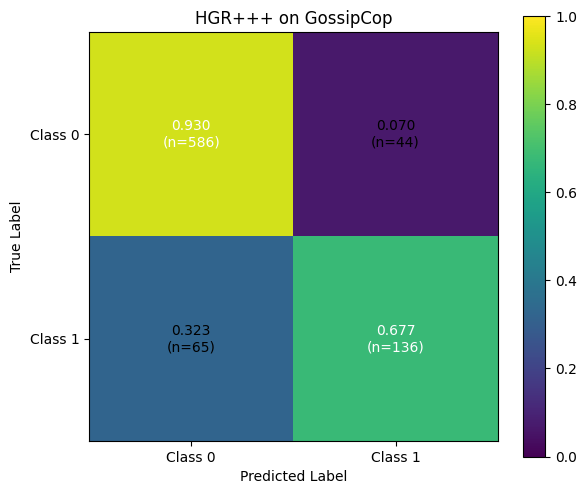


PAPER-READY SUMMARY


,Metric,Value
0,Accuracy,0.8688
1,Macro-Precision,0.8279
2,Macro-Recall,0.8034
3,Macro-F1,0.8144
4,Weighted-F1,0.8663
5,ROC-AUC,0.8809
6,Average Precision,0.7836
7,Class 0 F1,0.9149
8,Class 1 F1,0.7139



Paper confusion matrix:


,Predicted Class 0,Predicted Class 1
True Class 0,586,44
True Class 1,65,136



FILES SAVED
Output directory : /kaggle/working/HGRplusplus_GossipCop_Paper
Final metrics    : /kaggle/working/HGRplusplus_GossipCop_Paper/HGRplusplus_GossipCop_Final_Metrics.csv
Class report     : /kaggle/working/HGRplusplus_GossipCop_Paper/HGRplusplus_GossipCop_Classification_Report.csv
Training history : /kaggle/working/HGRplusplus_GossipCop_Paper/HGRplusplus_GossipCop_Training_History.csv
Predictions      : /kaggle/working/HGRplusplus_GossipCop_Paper/HGRplusplus_GossipCop_Test_Predictions.csv
Raw CM           : /kaggle/working/HGRplusplus_GossipCop_Paper/HGRplusplus_GossipCop_Confusion_Matrix.csv
Normalized CM    : /kaggle/working/HGRplusplus_GossipCop_Paper/HGRplusplus_GossipCop_Normalized_Confusion_Matrix.csv
Paper figure     : /kaggle/working/HGRplusplus_GossipCop_Paper/HGRplusplus_GossipCop_Normalized_Confusion_Matrix.png
Best model       : /kaggle/working/HGRplusplus_GossipCop_Paper/HGRplusplus_GossipCop_Best_Model.pt

Experiment complete.


In [5]:
# =========================================================
# HGR+++ — GOSSIPCOP EXTERNAL-DATASET EVALUATION
# ====================
# =============================================================================
# 1. IMPORTS
# =============================================================================

import os
import random
import warnings
import numpy as np
import pandas as pd
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    classification_report,
    confusion_matrix
)

import matplotlib.pyplot as plt

from transformers import CLIPModel, CLIPProcessor


warnings.filterwarnings("ignore")
os.environ["TOKENIZERS_PARALLELISM"] = "false"


# =============================================================================
# 2. REPRODUCIBILITY
# =============================================================================

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False


# =============================================================================
# 3. PATHS
# =============================================================================

CSV_PATH = (
    "/kaggle/input/datasets/rejuyanhossainshawon/"
    "clean-csv-with-images/gossipcop_multimodal_clean.csv"
)

IMAGE_DIR = (
    "/kaggle/input/datasets/rejuyanhossainshawon/"
    "gossipcop-image/images_best/images_best"
)

OUTPUT_DIR = "/kaggle/working/HGRplusplus_GossipCop_Paper"

os.makedirs(OUTPUT_DIR, exist_ok=True)

assert os.path.isfile(CSV_PATH), f"CSV not found: {CSV_PATH}"
assert os.path.isdir(IMAGE_DIR), f"Image directory not found: {IMAGE_DIR}"


# =============================================================================
# 4. CONFIGURATION
# =============================================================================

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

CLIP_MODEL_NAME = "openai/clip-vit-base-patch32"

MAX_TEXT_LENGTH = 77

TRAIN_BATCH_SIZE = 32
EVAL_BATCH_SIZE = 64

NUM_EPOCHS = 6

HEAD_LR = 2e-4
CLIP_LR = 1e-5

WEIGHT_DECAY = 1e-4
GRAD_CLIP_NORM = 1.0

LABEL_SMOOTHING = 0.02

CONTEXT_HIDDEN_DIM = 256
CATEGORY_EMBED_DIM = 32

GATE_HIDDEN_DIM = 256
CLASSIFIER_HIDDEN_DIM = 1024

DROPOUT = 0.20

GATE_TEMPERATURE = 2.0
GATE_REGULARIZATION = 0.005
GATE_TARGET_MEAN = 0.60

UNFREEZE_LAST_N_BLOCKS = 2

USE_AMP = True


print("=" * 78)
print("HGR+++ — GOSSIPCOP EXTERNAL-DATASET EVALUATION")
print("=" * 78)

print("Device               :", DEVICE)
print("Random seed          :", SEED)
print("CLIP backbone        :", CLIP_MODEL_NAME)
print("Epochs               :", NUM_EPOCHS)
print("Head LR              :", HEAD_LR)
print("CLIP LR              :", CLIP_LR)
print("Weight decay         :", WEIGHT_DECAY)
print("Label smoothing      :", LABEL_SMOOTHING)
print("Dropout              :", DROPOUT)
print("Gate temperature     :", GATE_TEMPERATURE)
print("Gate regularization  :", GATE_REGULARIZATION)
print("Gate target mean     :", GATE_TARGET_MEAN)
print("Unfrozen CLIP blocks :", UNFREEZE_LAST_N_BLOCKS)


# =============================================================================
# 5. CLIP PROCESSOR
# =============================================================================

processor = CLIPProcessor.from_pretrained(
    CLIP_MODEL_NAME
)


# =============================================================================
# 6. LOAD GOSSIPCOP
# =============================================================================

df = pd.read_csv(CSV_PATH)

ID_COL = "id"
TEXT_COL = "text"

FALLBACK_TEXT_COL = (
    "title_crawled"
    if "title_crawled" in df.columns
    else None
)

LOCAL_IMAGE_COL = "local_image"

HAS_LOCAL_IMAGE_COL = (
    "has_local_image"
    if "has_local_image" in df.columns
    else None
)

LABEL_COL = "label"


required_columns = [
    ID_COL,
    TEXT_COL,
    LOCAL_IMAGE_COL,
    LABEL_COL
]

missing_columns = [
    col for col in required_columns
    if col not in df.columns
]

if missing_columns:
    raise ValueError(
        f"Missing required columns: {missing_columns}"
    )


df[TEXT_COL] = (
    df[TEXT_COL]
    .fillna("")
    .astype(str)
)

if FALLBACK_TEXT_COL is not None:
    df[FALLBACK_TEXT_COL] = (
        df[FALLBACK_TEXT_COL]
        .fillna("")
        .astype(str)
    )

df[LOCAL_IMAGE_COL] = (
    df[LOCAL_IMAGE_COL]
    .fillna("")
    .astype(str)
)


if HAS_LOCAL_IMAGE_COL is not None:
    df = df[
        df[HAS_LOCAL_IMAGE_COL] == 1
    ].copy()

df = df[
    df[LOCAL_IMAGE_COL].str.len() > 0
].copy()

df = df.reset_index(drop=True)


# =============================================================================
# 7. LABEL ENCODING
# =============================================================================

raw_labels = df[LABEL_COL]

if raw_labels.dtype == object:

    labels_string = (
        raw_labels
        .fillna("UNK")
        .astype(str)
        .str.lower()
        .str.strip()
    )

    labels_string = labels_string.replace({
        "false": "fake",
        "true": "real"
    })

    if set(labels_string.unique()).issubset(
        {"fake", "real", "unk"}
    ):

        label_mapping = {
            "fake": 0,
            "real": 1,
            "unk": 0
        }

        df["label_int"] = (
            labels_string
            .map(label_mapping)
            .astype(int)
        )

    else:

        encoded, unique_labels = pd.factorize(
            labels_string
        )

        df["label_int"] = encoded.astype(int)

        print(
            "Label mapping:",
            {
                str(label): int(index)
                for index, label
                in enumerate(unique_labels)
            }
        )

else:

    df["label_int"] = (
        pd.to_numeric(
            raw_labels,
            errors="coerce"
        )
        .fillna(0)
        .astype(int)
    )


NUM_CLASSES = int(
    df["label_int"].nunique()
)

if NUM_CLASSES != 2:
    raise ValueError(
        f"Expected binary GossipCop labels, found {NUM_CLASSES} classes."
    )


print("\n" + "=" * 78)
print("DATASET SUMMARY")
print("=" * 78)

print("Total usable samples:", len(df))

print(
    "Class distribution:",
    df["label_int"]
    .value_counts()
    .sort_index()
    .to_dict()
)


# =============================================================================
# 8. AVAILABLE CONTEXTUAL/METADATA INPUTS
# =============================================================================

NUMERIC_METADATA_CANDIDATES = [
    "score",
    "num_comments",
    "upvote_ratio"
]

CATEGORICAL_METADATA_CANDIDATES = [
    "domain"
]

NUMERIC_METADATA_COLS = [
    col
    for col in NUMERIC_METADATA_CANDIDATES
    if col in df.columns
]

CATEGORICAL_METADATA_COLS = [
    col
    for col in CATEGORICAL_METADATA_CANDIDATES
    if col in df.columns
]


print("\nAvailable contextual fields:")

print(
    "Numeric:",
    NUMERIC_METADATA_COLS
)

print(
    "Categorical:",
    CATEGORICAL_METADATA_COLS
)

print(
    "Image presence: derived from successful local image loading"
)


# =============================================================================
# 9. REAL-IMAGE VALIDATION + STRATIFIED 80/10/10 SPLIT
# =============================================================================
# Images are resolved and decoded BEFORE splitting.
# Only genuinely readable RGB images are retained.
# This prevents fallback-image contamination of the multimodal experiment.

IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".webp", ".bmp"}

IMAGE_BY_FILENAME = {}
IMAGE_BY_STEM = {}
IMAGE_BY_ID_PREFIX = {}

for root, _, files in os.walk(IMAGE_DIR):
    for filename in files:
        ext = os.path.splitext(filename)[1].lower()
        if ext not in IMAGE_EXTENSIONS:
            continue

        full_path = os.path.join(root, filename)
        filename_lower = filename.lower()
        stem_lower = os.path.splitext(filename_lower)[0]

        IMAGE_BY_FILENAME[filename_lower] = full_path
        IMAGE_BY_STEM.setdefault(stem_lower, full_path)

        if "_" in stem_lower:
            prefix = stem_lower.split("_", 1)[0]
            IMAGE_BY_ID_PREFIX.setdefault(prefix, full_path)

print("\n" + "=" * 78)
print("IMAGE INDEX")
print("=" * 78)
print("Image directory :", IMAGE_DIR)
print("Indexed images  :", len(IMAGE_BY_FILENAME))


def clean_path_value(value):
    if value is None:
        return ""

    try:
        if pd.isna(value):
            return ""
    except Exception:
        pass

    value = str(value).replace("\\", "/").strip()

    if value.lower() in {"", "nan", "none", "null"}:
        return ""

    return value


def resolve_local_image_path(row):
   
    path = clean_path_value(row[LOCAL_IMAGE_COL])

    if path:
        if os.path.isfile(path):
            return path

        filename = os.path.basename(path).lower()

        if filename in IMAGE_BY_FILENAME:
            return IMAGE_BY_FILENAME[filename]

        stem = os.path.splitext(filename)[0]

        if stem in IMAGE_BY_STEM:
            return IMAGE_BY_STEM[stem]

        for extension in IMAGE_EXTENSIONS:
            candidate = filename + extension
            if candidate in IMAGE_BY_FILENAME:
                return IMAGE_BY_FILENAME[candidate]

 
    record_id = clean_path_value(row[ID_COL]).lower()

    if record_id:
        if record_id in IMAGE_BY_STEM:
            return IMAGE_BY_STEM[record_id]

        if record_id in IMAGE_BY_ID_PREFIX:
            return IMAGE_BY_ID_PREFIX[record_id]

        prefix = record_id + "_"
        for filename, full_path in IMAGE_BY_FILENAME.items():
            if filename.startswith(prefix):
                return full_path

    return None


def image_can_decode(path):
    if path is None or not os.path.isfile(path):
        return False

    try:
        with Image.open(path) as image:
            image = image.convert("RGB")
            image.load()
        return True
    except Exception:
        return False


print("\n" + "=" * 78)
print("PRE-SPLIT IMAGE VALIDATION")
print("=" * 78)

original_sample_count = len(df)
resolved_paths = []
readable_flags = []
bad_image_records = []

for i in range(len(df)):
    row = df.iloc[i]
    path = resolve_local_image_path(row)
    readable = image_can_decode(path)

    resolved_paths.append(path)
    readable_flags.append(readable)

    if not readable:
        bad_image_records.append({
            "row_index": i,
            "record_id": str(row[ID_COL]),
            "local_image": str(row[LOCAL_IMAGE_COL]),
            "resolved_path": path
        })

df["_resolved_image_path"] = resolved_paths
df["_image_readable"] = readable_flags

num_resolved = sum(
    path is not None and os.path.isfile(path)
    for path in resolved_paths
)
num_readable = int(np.sum(readable_flags))
num_removed = original_sample_count - num_readable

print("Original samples  :", original_sample_count)
print(f"Resolvable images : {num_resolved}/{original_sample_count}")
print(f"Readable images   : {num_readable}/{original_sample_count}")
print(f"Unreadable images : {num_removed}/{original_sample_count}")
print(
    f"Readable coverage : "
    f"{100.0 * num_readable / max(original_sample_count, 1):.2f}%"
)

if bad_image_records:
    bad_images_df = pd.DataFrame(bad_image_records)

    BAD_IMAGES_PATH = os.path.join(
        OUTPUT_DIR,
        "GossipCop_Removed_Unreadable_Images.csv"
    )
    bad_images_df.to_csv(BAD_IMAGES_PATH, index=False)

    print("\nRemoved unreadable samples:")
    display(bad_images_df)
    print("\nRemoved-image report:", BAD_IMAGES_PATH)
else:
    bad_images_df = pd.DataFrame()
    print("\nNo unreadable images found.")

# Retain only real, decodable text-image pairs.
df = df[df["_image_readable"]].copy().reset_index(drop=True)

print("\n" + "=" * 78)
print("FINAL MULTIMODAL DATASET")
print("=" * 78)
print("Original samples :", original_sample_count)
print("Removed samples  :", num_removed)
print("Final samples    :", len(df))
print(
    "Class distribution:",
    df["label_int"].value_counts().sort_index().to_dict()
)

assert len(df) == num_readable
assert df["_image_readable"].all()

for path in df["_resolved_image_path"]:
    assert path is not None and os.path.isfile(path)

print("\n✅ Final dataset contains only real, readable text-image pairs.")

# Stratified 80/10/10 split AFTER image validation.
train_df, temp_df = train_test_split(
    df,
    test_size=0.20,
    random_state=SEED,
    stratify=df["label_int"]
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    random_state=SEED,
    stratify=temp_df["label_int"]
)

train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print("\n" + "=" * 78)
print("FINAL DATASET SPLITS")
print("=" * 78)

print(
    f"Train      : {len(train_df)} | "
    f"{train_df['label_int'].value_counts().sort_index().to_dict()}"
)
print(
    f"Validation : {len(val_df)} | "
    f"{val_df['label_int'].value_counts().sort_index().to_dict()}"
)
print(
    f"Test       : {len(test_df)} | "
    f"{test_df['label_int'].value_counts().sort_index().to_dict()}"
)


# =============================================================================
# 10. NUMERIC NORMALIZATION — TRAIN ONLY
# =============================================================================

def safe_float(value, default=0.0):

    try:
        if pd.isna(value):
            return default

        return float(value)

    except Exception:
        return default


if len(NUMERIC_METADATA_COLS) > 0:

    train_numeric = np.stack(
        [
            np.array(
                [
                    safe_float(value)
                    for value
                    in train_df[col].values
                ],
                dtype=np.float32
            )
            for col in NUMERIC_METADATA_COLS
        ],
        axis=1
    )

    for j, col in enumerate(
        NUMERIC_METADATA_COLS
    ):

        if col in [
            "score",
            "num_comments"
        ]:

            train_numeric[:, j] = np.log1p(
                np.maximum(
                    train_numeric[:, j],
                    0
                )
            )

    numeric_mean = train_numeric.mean(
        axis=0
    )

    numeric_std = train_numeric.std(
        axis=0
    )

    numeric_std[
        numeric_std < 1e-6
    ] = 1.0


    def normalize_numeric(row):

        values = np.array(
            [
                safe_float(row[col])
                for col in NUMERIC_METADATA_COLS
            ],
            dtype=np.float32
        )

        for j, col in enumerate(
            NUMERIC_METADATA_COLS
        ):

            if col in [
                "score",
                "num_comments"
            ]:

                values[j] = np.log1p(
                    max(values[j], 0)
                )

        return (
            values - numeric_mean
        ) / numeric_std

else:

    def normalize_numeric(row):

        return np.zeros(
            (0,),
            dtype=np.float32
        )


# =============================================================================
# 11. CATEGORICAL VOCABULARIES — TRAIN ONLY
# =============================================================================

def build_category_vocab(series):

    values = (
        series
        .fillna("UNK")
        .astype(str)
        .tolist()
    )

    return {
        value: index + 1
        for index, value
        in enumerate(sorted(set(values)))
    }


category_vocabs = {
    col: build_category_vocab(
        train_df[col]
    )
    for col in CATEGORICAL_METADATA_COLS
}


def category_to_id(col, value):

    if pd.isna(value):
        value = "UNK"

    return category_vocabs[col].get(
        str(value),
        0
    )


# =============================================================================
# 12. LOCAL IMAGE LOADING — VALIDATED IMAGES ONLY
# =============================================================================

def load_local_image(path):
    if path is None or not os.path.isfile(path):
        raise RuntimeError(
            f"Validated image path is missing during training: {path}"
        )

    try:
        with Image.open(path) as image:
            image = image.convert("RGB").copy()
        return image, True

    except Exception as exc:
        raise RuntimeError(
            f"Validated image unexpectedly failed during training: {path}"
        ) from exc


# =============================================================================
# 13. FINAL IMAGE SAFETY CHECK
# =============================================================================

print("\n" + "=" * 78)
print("FINAL IMAGE CHECK")
print("=" * 78)
print(f"Training-ready images: {len(df)}/{len(df)}")
print("Fallback images       : 0")
print("✅ Image validation completed before splitting.")


# =============================================================================
# 14. PYTORCH DATASET
# =============================================================================

class GossipCopDataset(Dataset):

    def __init__(self, dataframe):

        self.df = dataframe.reset_index(
            drop=True
        )


    def __len__(self):

        return len(self.df)


    def __getitem__(self, index):

        row = self.df.iloc[index]

        text = str(
            row[TEXT_COL]
        )

        if (
            len(text.strip()) == 0
            and FALLBACK_TEXT_COL is not None
        ):

            fallback_text = str(
                row[FALLBACK_TEXT_COL]
            )

            if len(
                fallback_text.strip()
            ) > 0:
                text = fallback_text


        image_path = row[
            "_resolved_image_path"
        ]

        image, image_loaded = load_local_image(
            image_path
        )

        if not image_loaded:
            raise RuntimeError(
                f"Validated image unexpectedly failed: {image_path}"
            )

        has_image = 1.0

        numeric_features = normalize_numeric(
            row
        )


        if len(
            CATEGORICAL_METADATA_COLS
        ) > 0:

            categorical_ids = np.array(
                [
                    category_to_id(
                        col,
                        row[col]
                    )
                    for col
                    in CATEGORICAL_METADATA_COLS
                ],
                dtype=np.int64
            )

        else:

            categorical_ids = np.zeros(
                (0,),
                dtype=np.int64
            )


        return {
            "id":
                str(row[ID_COL]),

            "text":
                text,

            "image":
                image,

            "labels":
                int(row["label_int"]),

            "numeric":
                torch.tensor(
                    numeric_features,
                    dtype=torch.float32
                ),

            "has_image":
                torch.tensor(
                    [has_image],
                    dtype=torch.float32
                ),

            "categorical_ids":
                torch.tensor(
                    categorical_ids,
                    dtype=torch.long
                )
        }


# =============================================================================
# 15. COLLATE
# =============================================================================

def collate_fn(batch):

    inputs = processor(
        text=[
            item["text"]
            for item in batch
        ],
        images=[
            item["image"]
            for item in batch
        ],
        return_tensors="pt",
        padding=True,
        truncation=True,
        max_length=MAX_TEXT_LENGTH
    )

    inputs["labels"] = torch.tensor(
        [
            item["labels"]
            for item in batch
        ],
        dtype=torch.long
    )

    inputs["numeric"] = torch.stack(
        [
            item["numeric"]
            for item in batch
        ]
    )

    inputs["has_image"] = torch.stack(
        [
            item["has_image"]
            for item in batch
        ]
    )

    if len(
        CATEGORICAL_METADATA_COLS
    ) > 0:

        inputs["categorical_ids"] = (
            torch.stack(
                [
                    item["categorical_ids"]
                    for item in batch
                ]
            )
        )

    else:

        inputs["categorical_ids"] = (
            torch.zeros(
                (len(batch), 0),
                dtype=torch.long
            )
        )

    inputs["record_ids"] = [
        item["id"]
        for item in batch
    ]

    return inputs


# =============================================================================
# 16. DATA LOADERS
# =============================================================================

train_loader = DataLoader(
    GossipCopDataset(train_df),
    batch_size=TRAIN_BATCH_SIZE,
    shuffle=True,
    collate_fn=collate_fn,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    GossipCopDataset(val_df),
    batch_size=EVAL_BATCH_SIZE,
    shuffle=False,
    collate_fn=collate_fn,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    GossipCopDataset(test_df),
    batch_size=EVAL_BATCH_SIZE,
    shuffle=False,
    collate_fn=collate_fn,
    num_workers=2,
    pin_memory=True
)


# =============================================================================
# 17. HGR+++ MODEL
# =============================================================================

class HGRPlusPlus(nn.Module):

    """
    HGR+++ — Hierarchical Gated Residual Fusion

    CLIP text representation  = 512
    CLIP image representation = 512

    z_clip = [normalized text ; normalized image]

    compressed multimodal representation:
        1024 -> 128

    context representation:
        available contextual inputs + compressed z_clip
        -> 256

    z0:
        [z_clip ; context] = 1280 dimensions

    feature-wise gate:
        context -> 256 -> 1280 -> sigmoid

    centered gated residual:
        z = z0 + z0 * (gate - 0.5)

    classifier:
        1280 -> 1024 -> 2
    """

    def __init__(
        self,
        clip_model_name,
        num_classes,
        context_hidden_dim=256,
        category_embedding_dim=32,
        gate_hidden_dim=256,
        classifier_hidden_dim=1024,
        dropout=0.20,
        gate_temperature=2.0
    ):

        super().__init__()

        self.clip = CLIPModel.from_pretrained(
            clip_model_name
        )

        self.gate_temperature = (
            gate_temperature
        )

        projection_dim = (
            self.clip.config.projection_dim
        )

        clip_fused_dim = (
            2 * projection_dim
        )


        self.category_embeddings = nn.ModuleList(
            [
                nn.Embedding(
                    len(
                        category_vocabs[col]
                    ) + 1,
                    category_embedding_dim
                )
                for col
                in CATEGORICAL_METADATA_COLS
            ]
        )


        self.clip_compression = nn.Sequential(
            nn.Linear(
                clip_fused_dim,
                128
            ),
            nn.ReLU(),
            nn.Dropout(dropout)
        )


        context_input_dim = (
            len(NUMERIC_METADATA_COLS)
            + 1
            + (
                len(
                    CATEGORICAL_METADATA_COLS
                )
                * category_embedding_dim
            )
            + 128
        )


        self.context_mlp = nn.Sequential(
            nn.Linear(
                context_input_dim,
                context_hidden_dim
            ),
            nn.ReLU(),
            nn.Dropout(dropout)
        )


        self.fused_dim = (
            clip_fused_dim
            + context_hidden_dim
        )


        self.gate_network = nn.Sequential(
            nn.Linear(
                context_hidden_dim,
                gate_hidden_dim
            ),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(
                gate_hidden_dim,
                self.fused_dim
            )
        )


        self.classifier = nn.Sequential(
            nn.Linear(
                self.fused_dim,
                classifier_hidden_dim
            ),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(
                classifier_hidden_dim,
                num_classes
            )
        )


    def forward(
        self,
        input_ids,
        attention_mask,
        pixel_values,
        numeric,
        has_image,
        categorical_ids,
        return_gate=False
    ):

        clip_outputs = self.clip(
            input_ids=input_ids,
            attention_mask=attention_mask,
            pixel_values=pixel_values
        )


        text_embedding = F.normalize(
            clip_outputs.text_embeds,
            p=2,
            dim=1
        )

        image_embedding = F.normalize(
            clip_outputs.image_embeds,
            p=2,
            dim=1
        )


        z_clip = torch.cat(
            [
                text_embedding,
                image_embedding
            ],
            dim=1
        )


        compressed_clip = (
            self.clip_compression(
                z_clip
            )
        )


        if len(
            CATEGORICAL_METADATA_COLS
        ) > 0:

            categorical_embedding = (
                torch.cat(
                    [
                        embedding(
                            categorical_ids[:, i]
                        )
                        for i, embedding
                        in enumerate(
                            self.category_embeddings
                        )
                    ],
                    dim=1
                )
            )

        else:

            categorical_embedding = (
                torch.empty(
                    (
                        numeric.size(0),
                        0
                    ),
                    device=numeric.device
                )
            )


        context_input = torch.cat(
            [
                numeric,
                has_image,
                categorical_embedding,
                compressed_clip
            ],
            dim=1
        )


        context = self.context_mlp(
            context_input
        )


        z0 = torch.cat(
            [
                z_clip,
                context
            ],
            dim=1
        )


        gate_logits = self.gate_network(
            context
        )

        gate = torch.sigmoid(
            gate_logits
            / self.gate_temperature
        )


        # HGR+++ centered gated residual fusion
        z = z0 + z0 * (
            gate - 0.5
        )


        logits = self.classifier(
            z
        )


        if return_gate:
            return logits, gate

        return logits


# =============================================================================
# 18. INITIALIZE MODEL
# =============================================================================

model = HGRPlusPlus(
    clip_model_name=CLIP_MODEL_NAME,
    num_classes=NUM_CLASSES,
    context_hidden_dim=CONTEXT_HIDDEN_DIM,
    category_embedding_dim=CATEGORY_EMBED_DIM,
    gate_hidden_dim=GATE_HIDDEN_DIM,
    classifier_hidden_dim=CLASSIFIER_HIDDEN_DIM,
    dropout=DROPOUT,
    gate_temperature=GATE_TEMPERATURE
).to(DEVICE)


for parameter in model.clip.parameters():
    parameter.requires_grad = False


def unfreeze_last_clip_blocks(
    clip_model,
    n_blocks=2
):

    text_blocks = (
        clip_model
        .text_model
        .encoder
        .layers
    )

    for block in text_blocks[-n_blocks:]:

        for parameter in block.parameters():
            parameter.requires_grad = True


    vision_blocks = (
        clip_model
        .vision_model
        .encoder
        .layers
    )

    for block in vision_blocks[-n_blocks:]:

        for parameter in block.parameters():
            parameter.requires_grad = True


unfreeze_last_clip_blocks(
    model.clip,
    n_blocks=UNFREEZE_LAST_N_BLOCKS
)


total_parameters = sum(
    p.numel()
    for p in model.parameters()
)

trainable_parameters = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)


print("\n" + "=" * 78)
print("MODEL SUMMARY")
print("=" * 78)

print(
    f"Total parameters     : "
    f"{total_parameters:,}"
)

print(
    f"Trainable parameters : "
    f"{trainable_parameters:,}"
)

print(
    f"Fine-tuned CLIP      : "
    f"last {UNFREEZE_LAST_N_BLOCKS} "
    f"text + vision blocks"
)


# =============================================================================
# 20. CLASS-WEIGHTED LABEL-SMOOTHED CROSS-ENTROPY
# =============================================================================

class LabelSmoothedWeightedCE(nn.Module):

    def __init__(
        self,
        smoothing=0.02,
        weight=None
    ):

        super().__init__()

        self.smoothing = smoothing
        self.weight = weight


    def forward(
        self,
        logits,
        target
    ):

        log_probabilities = F.log_softmax(
            logits,
            dim=-1
        )

        num_classes = logits.size(-1)


        with torch.no_grad():

            target_distribution = (
                torch.zeros_like(
                    log_probabilities
                )
            )

            target_distribution.fill_(
                self.smoothing
                / max(
                    num_classes - 1,
                    1
                )
            )

            target_distribution.scatter_(
                1,
                target.unsqueeze(1),
                1.0 - self.smoothing
            )


            if self.weight is not None:

                target_distribution = (
                    target_distribution
                    * self.weight.view(
                        1,
                        -1
                    )
                )

                target_distribution = (
                    target_distribution
                    / target_distribution.sum(
                        dim=1,
                        keepdim=True
                    )
                )


        return -(
            target_distribution
            * log_probabilities
        ).sum(
            dim=1
        ).mean()


training_class_counts = (
    train_df["label_int"]
    .value_counts()
    .sort_index()
    .reindex(
        range(NUM_CLASSES),
        fill_value=0
    )
    .values
)


class_weights = (
    training_class_counts.sum()
    / (
        NUM_CLASSES
        * np.maximum(
            training_class_counts,
            1
        )
    )
)


class_weights_tensor = torch.tensor(
    class_weights,
    dtype=torch.float32,
    device=DEVICE
)


criterion = LabelSmoothedWeightedCE(
    smoothing=LABEL_SMOOTHING,
    weight=class_weights_tensor
)


print("\nClass weights:")

for class_id, weight in enumerate(
    class_weights
):

    print(
        f"Class {class_id}: "
        f"{weight:.4f}"
    )


# =============================================================================
# 21. OPTIMIZER
# =============================================================================

head_parameters = []
clip_parameters = []


for name, parameter in model.named_parameters():

    if not parameter.requires_grad:
        continue

    if "clip." in name:
        clip_parameters.append(
            parameter
        )

    else:
        head_parameters.append(
            parameter
        )


optimizer = torch.optim.AdamW(
    [
        {
            "params": head_parameters,
            "lr": HEAD_LR
        },
        {
            "params": clip_parameters,
            "lr": CLIP_LR
        }
    ],
    weight_decay=WEIGHT_DECAY
)


scaler = torch.cuda.amp.GradScaler(
    enabled=(
        USE_AMP
        and DEVICE.type == "cuda"
    )
)


# =============================================================================
# 22. EVALUATION FUNCTION
# =============================================================================

def evaluate_model(
    model,
    loader,
    collect_ids=False
):

    model.eval()

    all_true = []
    all_pred = []
    all_prob = []
    all_ids = []


    with torch.no_grad():

        for batch in loader:

            with torch.cuda.amp.autocast(
                enabled=(
                    USE_AMP
                    and DEVICE.type == "cuda"
                )
            ):

                logits = model(
                    batch["input_ids"].to(
                        DEVICE
                    ),
                    batch[
                        "attention_mask"
                    ].to(
                        DEVICE
                    ),
                    batch[
                        "pixel_values"
                    ].to(
                        DEVICE
                    ),
                    batch[
                        "numeric"
                    ].to(
                        DEVICE
                    ),
                    batch[
                        "has_image"
                    ].to(
                        DEVICE
                    ),
                    batch[
                        "categorical_ids"
                    ].to(
                        DEVICE
                    )
                )


            probabilities = torch.softmax(
                logits,
                dim=1
            )

            predictions = torch.argmax(
                probabilities,
                dim=1
            )


            all_true.append(
                batch["labels"]
                .cpu()
                .numpy()
            )

            all_pred.append(
                predictions
                .cpu()
                .numpy()
            )

            all_prob.append(
                probabilities
                .cpu()
                .numpy()
            )


            if collect_ids:
                all_ids.extend(
                    batch["record_ids"]
                )


    y_true = np.concatenate(
        all_true
    )

    y_pred = np.concatenate(
        all_pred
    )

    y_prob = np.concatenate(
        all_prob
    )


    results = {

        "accuracy":
            accuracy_score(
                y_true,
                y_pred
            ),

        "macro_precision":
            precision_score(
                y_true,
                y_pred,
                average="macro",
                zero_division=0
            ),

        "macro_recall":
            recall_score(
                y_true,
                y_pred,
                average="macro",
                zero_division=0
            ),

        "macro_f1":
            f1_score(
                y_true,
                y_pred,
                average="macro",
                zero_division=0
            ),

        "weighted_precision":
            precision_score(
                y_true,
                y_pred,
                average="weighted",
                zero_division=0
            ),

        "weighted_recall":
            recall_score(
                y_true,
                y_pred,
                average="weighted",
                zero_division=0
            ),

        "weighted_f1":
            f1_score(
                y_true,
                y_pred,
                average="weighted",
                zero_division=0
            ),

        "roc_auc":
            roc_auc_score(
                y_true,
                y_prob[:, 1]
            ),

        "average_precision":
            average_precision_score(
                y_true,
                y_prob[:, 1]
            ),

        "y_true":
            y_true,

        "y_pred":
            y_pred,

        "y_prob":
            y_prob,

        "record_ids":
            all_ids
    }


    return results


# =============================================================================
# 23. TRAINING
# =============================================================================

best_validation_macro_f1 = -1.0
best_epoch = None
best_state = None

training_history = []


print("\n" + "=" * 78)
print("TRAINING")
print("=" * 78)


for epoch in range(
    1,
    NUM_EPOCHS + 1
):

    model.train()

    total_training_loss = 0.0
    gate_means = []


    for batch in train_loader:

        optimizer.zero_grad(
            set_to_none=True
        )


        with torch.cuda.amp.autocast(
            enabled=(
                USE_AMP
                and DEVICE.type == "cuda"
            )
        ):

            logits, gate = model(
                batch[
                    "input_ids"
                ].to(
                    DEVICE
                ),
                batch[
                    "attention_mask"
                ].to(
                    DEVICE
                ),
                batch[
                    "pixel_values"
                ].to(
                    DEVICE
                ),
                batch[
                    "numeric"
                ].to(
                    DEVICE
                ),
                batch[
                    "has_image"
                ].to(
                    DEVICE
                ),
                batch[
                    "categorical_ids"
                ].to(
                    DEVICE
                ),
                return_gate=True
            )


            labels = batch[
                "labels"
            ].to(
                DEVICE
            )


            classification_loss = criterion(
                logits,
                labels
            )


            gate_mean = gate.mean()


            gate_regularization_loss = (
                GATE_REGULARIZATION
                * torch.abs(
                    gate_mean
                    - GATE_TARGET_MEAN
                )
            )


            loss = (
                classification_loss
                + gate_regularization_loss
            )


        scaler.scale(
            loss
        ).backward()


        scaler.unscale_(
            optimizer
        )


        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            GRAD_CLIP_NORM
        )


        scaler.step(
            optimizer
        )

        scaler.update()


        total_training_loss += (
            loss.item()
        )

        gate_means.append(
            gate_mean.detach().item()
        )


    average_training_loss = (
        total_training_loss
        / max(
            len(train_loader),
            1
        )
    )

    average_gate_mean = float(
        np.mean(gate_means)
    )


    validation_results = evaluate_model(
        model,
        val_loader
    )


    training_history.append({
        "epoch":
            epoch,

        "train_loss":
            average_training_loss,

        "val_accuracy":
            validation_results[
                "accuracy"
            ],

        "val_macro_precision":
            validation_results[
                "macro_precision"
            ],

        "val_macro_recall":
            validation_results[
                "macro_recall"
            ],

        "val_macro_f1":
            validation_results[
                "macro_f1"
            ],

        "val_weighted_f1":
            validation_results[
                "weighted_f1"
            ],

        "val_roc_auc":
            validation_results[
                "roc_auc"
            ],

        "gate_mean":
            average_gate_mean
    })


    print(
        f"Epoch {epoch}/{NUM_EPOCHS} | "
        f"loss={average_training_loss:.4f} | "
        f"val_acc={validation_results['accuracy']:.4f} | "
        f"val_macroF1={validation_results['macro_f1']:.4f} | "
        f"val_weightedF1={validation_results['weighted_f1']:.4f} | "
        f"val_AUC={validation_results['roc_auc']:.4f} | "
        f"gate_mean={average_gate_mean:.3f}"
    )


    # Select checkpoint ONLY using validation Macro-F1
    if (
        validation_results[
            "macro_f1"
        ]
        > best_validation_macro_f1
    ):

        best_validation_macro_f1 = (
            validation_results[
                "macro_f1"
            ]
        )

        best_epoch = epoch

        best_state = {
            key:
                value.detach()
                .cpu()
                .clone()

            for key, value
            in model.state_dict().items()
        }

        print(
            ">>> Best checkpoint updated"
        )


# =============================================================================
# 24. RESTORE BEST VALIDATION CHECKPOINT
# =============================================================================

if best_state is None:
    raise RuntimeError(
        "No checkpoint was created."
    )


model.load_state_dict(
    best_state
)


print("\n" + "=" * 78)
print("BEST CHECKPOINT")
print("=" * 78)

print(
    f"Best epoch               : {best_epoch}"
)

print(
    f"Best validation Macro-F1 : "
    f"{best_validation_macro_f1:.4f}"
)


# =============================================================================
# 25. FINAL TEST EVALUATION
# =============================================================================

test_results = evaluate_model(
    model,
    test_loader,
    collect_ids=True
)


y_true = test_results[
    "y_true"
]

y_pred = test_results[
    "y_pred"
]

y_prob = test_results[
    "y_prob"
]


print("\n" + "=" * 78)
print("FINAL TEST RESULTS — HGR+++ ON GOSSIPCOP")
print("=" * 78)

print(
    f"Accuracy           : "
    f"{test_results['accuracy']:.4f}"
)

print(
    f"Macro-Precision    : "
    f"{test_results['macro_precision']:.4f}"
)

print(
    f"Macro-Recall       : "
    f"{test_results['macro_recall']:.4f}"
)

print(
    f"Macro-F1           : "
    f"{test_results['macro_f1']:.4f}"
)

print(
    f"Weighted-Precision : "
    f"{test_results['weighted_precision']:.4f}"
)

print(
    f"Weighted-Recall    : "
    f"{test_results['weighted_recall']:.4f}"
)

print(
    f"Weighted-F1        : "
    f"{test_results['weighted_f1']:.4f}"
)

print(
    f"ROC-AUC            : "
    f"{test_results['roc_auc']:.4f}"
)

print(
    f"Average Precision  : "
    f"{test_results['average_precision']:.4f}"
)


# =============================================================================
# 26. PER-CLASS CLASSIFICATION REPORT
# =============================================================================

print("\n" + "=" * 78)
print("PER-CLASS CLASSIFICATION REPORT")
print("=" * 78)

print(
    classification_report(
        y_true,
        y_pred,
        digits=4,
        zero_division=0
    )
)


report_dict = classification_report(
    y_true,
    y_pred,
    output_dict=True,
    zero_division=0
)

report_df = pd.DataFrame(
    report_dict
).transpose()


# =============================================================================
# 27. CONFUSION MATRICES
# =============================================================================

cm = confusion_matrix(
    y_true,
    y_pred
)

cm_normalized = confusion_matrix(
    y_true,
    y_pred,
    normalize="true"
)


print("=" * 78)
print("CONFUSION MATRIX")
print("=" * 78)

print(cm)


print("\nNormalized confusion matrix:")

print(
    np.round(
        cm_normalized,
        4
    )
)


# =============================================================================
# 28. FIGURE — NORMALIZED CONFUSION MATRIX
# =============================================================================

CLASS_NAMES = [
    "Class 0",
    "Class 1"
]


fig, ax = plt.subplots(
    figsize=(6.2, 5.2)
)


image = ax.imshow(
    cm_normalized,
    interpolation="nearest",
    vmin=0,
    vmax=1
)


fig.colorbar(
    image,
    ax=ax
)


ax.set(
    xticks=np.arange(NUM_CLASSES),
    yticks=np.arange(NUM_CLASSES),
    xticklabels=CLASS_NAMES,
    yticklabels=CLASS_NAMES,
    xlabel="Predicted Label",
    ylabel="True Label",
    title="HGR+++ on GossipCop"
)


for i in range(
    cm_normalized.shape[0]
):

    for j in range(
        cm_normalized.shape[1]
    ):

        value = cm_normalized[i, j]

        count = cm[i, j]

        ax.text(
            j,
            i,
            f"{value:.3f}\n(n={count})",
            ha="center",
            va="center",
            color=(
                "white"
                if value > 0.50
                else "black"
            )
        )


plt.tight_layout()


FIGURE_PATH = os.path.join(
    OUTPUT_DIR,
    "HGRplusplus_GossipCop_Normalized_Confusion_Matrix.png"
)


plt.savefig(
    FIGURE_PATH,
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# =============================================================================
# 29. SAVE TRAINING HISTORY
# =============================================================================

history_df = pd.DataFrame(
    training_history
)


HISTORY_PATH = os.path.join(
    OUTPUT_DIR,
    "HGRplusplus_GossipCop_Training_History.csv"
)


history_df.to_csv(
    HISTORY_PATH,
    index=False
)


# =============================================================================
# 30. SAVE CLASSIFICATION REPORT
# =============================================================================

REPORT_PATH = os.path.join(
    OUTPUT_DIR,
    "HGRplusplus_GossipCop_Classification_Report.csv"
)


report_df.to_csv(
    REPORT_PATH
)


# =============================================================================
# 31. SAVE TEST PREDICTIONS
# =============================================================================

predictions_df = pd.DataFrame({

    "record_id":
        test_results[
            "record_ids"
        ],

    "true_label":
        y_true,

    "predicted_label":
        y_pred,

    "probability_class_0":
        y_prob[:, 0],

    "probability_class_1":
        y_prob[:, 1]
})


PREDICTIONS_PATH = os.path.join(
    OUTPUT_DIR,
    "HGRplusplus_GossipCop_Test_Predictions.csv"
)


predictions_df.to_csv(
    PREDICTIONS_PATH,
    index=False
)


# =============================================================================
# 32. SAVE FINAL METRICS
# =============================================================================

class_0_precision = precision_score(
    y_true,
    y_pred,
    labels=[0],
    average=None,
    zero_division=0
)[0]

class_0_recall = recall_score(
    y_true,
    y_pred,
    labels=[0],
    average=None,
    zero_division=0
)[0]

class_0_f1 = f1_score(
    y_true,
    y_pred,
    labels=[0],
    average=None,
    zero_division=0
)[0]


class_1_precision = precision_score(
    y_true,
    y_pred,
    labels=[1],
    average=None,
    zero_division=0
)[0]

class_1_recall = recall_score(
    y_true,
    y_pred,
    labels=[1],
    average=None,
    zero_division=0
)[0]

class_1_f1 = f1_score(
    y_true,
    y_pred,
    labels=[1],
    average=None,
    zero_division=0
)[0]


final_metrics = {

    "Model":
        "HGR+++",

    "Dataset":
        "GossipCop",

    "Train_Samples":
        len(train_df),

    "Validation_Samples":
        len(val_df),

    "Test_Samples":
        len(test_df),

    "Best_Epoch":
        best_epoch,

    "Best_Validation_Macro_F1":
        best_validation_macro_f1,

    "Accuracy":
        test_results[
            "accuracy"
        ],

    "Macro_Precision":
        test_results[
            "macro_precision"
        ],

    "Macro_Recall":
        test_results[
            "macro_recall"
        ],

    "Macro_F1":
        test_results[
            "macro_f1"
        ],

    "Weighted_Precision":
        test_results[
            "weighted_precision"
        ],

    "Weighted_Recall":
        test_results[
            "weighted_recall"
        ],

    "Weighted_F1":
        test_results[
            "weighted_f1"
        ],

    "ROC_AUC":
        test_results[
            "roc_auc"
        ],

    "Average_Precision":
        test_results[
            "average_precision"
        ],

    "Class_0_Precision":
        class_0_precision,

    "Class_0_Recall":
        class_0_recall,

    "Class_0_F1":
        class_0_f1,

    "Class_1_Precision":
        class_1_precision,

    "Class_1_Recall":
        class_1_recall,

    "Class_1_F1":
        class_1_f1
}


final_metrics_df = pd.DataFrame(
    [final_metrics]
)


METRICS_PATH = os.path.join(
    OUTPUT_DIR,
    "HGRplusplus_GossipCop_Final_Metrics.csv"
)


final_metrics_df.to_csv(
    METRICS_PATH,
    index=False
)


# =============================================================================
# 33. SAVE RAW + NORMALIZED CONFUSION MATRICES
# =============================================================================

CM_PATH = os.path.join(
    OUTPUT_DIR,
    "HGRplusplus_GossipCop_Confusion_Matrix.csv"
)

NCM_PATH = os.path.join(
    OUTPUT_DIR,
    "HGRplusplus_GossipCop_Normalized_Confusion_Matrix.csv"
)


pd.DataFrame(
    cm,
    index=[
        "True_Class_0",
        "True_Class_1"
    ],
    columns=[
        "Predicted_Class_0",
        "Predicted_Class_1"
    ]
).to_csv(
    CM_PATH
)


pd.DataFrame(
    cm_normalized,
    index=[
        "True_Class_0",
        "True_Class_1"
    ],
    columns=[
        "Predicted_Class_0",
        "Predicted_Class_1"
    ]
).to_csv(
    NCM_PATH
)


# =============================================================================
# 34. SAVE BEST MODEL
# =============================================================================

MODEL_PATH = os.path.join(
    OUTPUT_DIR,
    "HGRplusplus_GossipCop_Best_Model.pt"
)


torch.save(
    {
        "model_state_dict":
            model.state_dict(),

        "best_epoch":
            best_epoch,

        "best_validation_macro_f1":
            best_validation_macro_f1,

        "seed":
            SEED,

        "clip_model":
            CLIP_MODEL_NAME,

        "num_classes":
            NUM_CLASSES,

        "class_weights":
            class_weights.tolist(),

        "configuration": {

            "train_batch_size":
                TRAIN_BATCH_SIZE,

            "eval_batch_size":
                EVAL_BATCH_SIZE,

            "epochs":
                NUM_EPOCHS,

            "head_lr":
                HEAD_LR,

            "clip_lr":
                CLIP_LR,

            "weight_decay":
                WEIGHT_DECAY,

            "label_smoothing":
                LABEL_SMOOTHING,

            "dropout":
                DROPOUT,

            "gate_temperature":
                GATE_TEMPERATURE,

            "gate_regularization":
                GATE_REGULARIZATION,

            "gate_target_mean":
                GATE_TARGET_MEAN,

            "unfreeze_last_n_blocks":
                UNFREEZE_LAST_N_BLOCKS
        }
    },
    MODEL_PATH
)


# =============================================================================
# 35. FINAL SUMMARY
# =============================================================================

print("\n" + "=" * 78)
print("PAPER-READY SUMMARY")
print("=" * 78)


summary_table = pd.DataFrame({

    "Metric": [
        "Accuracy",
        "Macro-Precision",
        "Macro-Recall",
        "Macro-F1",
        "Weighted-F1",
        "ROC-AUC",
        "Average Precision",
        "Class 0 F1",
        "Class 1 F1"
    ],

    "Value": [
        test_results["accuracy"],
        test_results["macro_precision"],
        test_results["macro_recall"],
        test_results["macro_f1"],
        test_results["weighted_f1"],
        test_results["roc_auc"],
        test_results["average_precision"],
        class_0_f1,
        class_1_f1
    ]
})


display(
    summary_table.round(4)
)


print("\nPaper confusion matrix:")

display(
    pd.DataFrame(
        cm,
        index=[
            "True Class 0",
            "True Class 1"
        ],
        columns=[
            "Predicted Class 0",
            "Predicted Class 1"
        ]
    )
)


print("\n" + "=" * 78)
print("FILES SAVED")
print("=" * 78)

print(
    "Output directory :",
    OUTPUT_DIR
)

print(
    "Final metrics    :",
    METRICS_PATH
)

print(
    "Class report     :",
    REPORT_PATH
)

print(
    "Training history :",
    HISTORY_PATH
)

print(
    "Predictions      :",
    PREDICTIONS_PATH
)

print(
    "Raw CM           :",
    CM_PATH
)

print(
    "Normalized CM    :",
    NCM_PATH
)

print(
    "Paper figure     :",
    FIGURE_PATH
)

print(
    "Best model       :",
    MODEL_PATH
)

print("\nExperiment complete.")